# 🎮 Gaming Addiction Risk Prediction  
## 🚀 Using Gradient Boosting & XGBoost

---

### 👨‍💻 Project Objective

The goal of this project is to predict gaming addiction risk levels using behavioral and mental health data.

We use machine learning classification models to understand how gaming habits affect addiction levels.

---

## 1. Introduction

Gaming has become a central part of modern digital entertainment, particularly among adolescents and young adults. While gaming can provide enjoyment, social interaction, and even cognitive benefits, excessive gaming behavior may lead to serious negative consequences such as sleep deprivation, reduced academic or work performance, social isolation, and psychological distress.

In recent years, there has been increasing interest in understanding gaming addiction as a behavioral health issue. Identifying early indicators of addiction risk can help researchers and practitioners design better interventions and promote healthier gaming habits.

In this project, we apply machine learning classification techniques to predict **gaming addiction risk level** using behavioral, physical, and psychological features. The target variable is **`gaming_addiction_risk_level`**, which represents different levels of addiction severity (Low, Moderate, High, Severe).

To solve this problem, we use two ensemble-based boosting algorithms:

- **Gradient Boosting Classifier**
- **XGBoost (Extreme Gradient Boosting)**

These models are particularly suitable for structured data and are capable of capturing complex, non-linear relationships between features.

The project follows a complete machine learning workflow:
1. Understanding the dataset  
2. Performing exploratory data analysis (EDA)  
3. Preprocessing and cleaning the data  
4. Training baseline models  
5. Improving the best model using advanced techniques  
6. Evaluating and interpreting the results  

The main objective is to bridge the gap between machine learning theory and real-world application by building a reliable model for predicting gaming addiction risk.

## 2. Algorithm Explanation

### 2.1 What is Gradient Boosting?

Gradient Boosting is an ensemble learning algorithm that builds a strong predictive model by combining multiple weak learners, typically decision trees. Instead of training one complex model, Gradient Boosting trains many small trees sequentially, where each new tree focuses on correcting the errors made by the previous ones.

---

### 2.2 How does Gradient Boosting work?

The algorithm works iteratively as follows:

1. Start with an initial prediction (usually a simple model)
2. Compute the error (residuals) between predicted and actual values
3. Train a new decision tree to predict these errors
4. Add this new tree to the model to improve predictions
5. Repeat this process multiple times

Each tree is added in a way that minimizes a loss function, which is why the method is called "gradient" boosting.

---

### 2.3 What is XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced and optimized implementation of Gradient Boosting. It improves performance by introducing:

- regularization (to prevent overfitting)
- efficient handling of missing values
- parallel processing for faster computation
- advanced tree pruning techniques

XGBoost is widely used in real-world machine learning applications and data science competitions due to its strong predictive power.

---

### 2.4 How does XGBoost work?

XGBoost follows the same boosting concept as Gradient Boosting but enhances it by:

- using second-order derivatives for better optimization
- adding regularization terms to control model complexity
- automatically handling missing data
- optimizing memory and computation efficiency

These improvements make XGBoost faster and more accurate than standard Gradient Boosting in many cases.

---

### 2.5 When should these algorithms be used?

Gradient Boosting and XGBoost are most suitable when:

- the dataset is structured (tabular data)
- relationships between variables are complex and non-linear
- high predictive performance is required
- both numerical and categorical features are present (after preprocessing)

They are commonly used in classification, regression, and ranking problems.

---

### 2.6 Advantages

- High predictive accuracy  
- Ability to model complex relationships  
- Works well with structured/tabular data  
- Handles feature interactions effectively  
- XGBoost includes regularization to reduce overfitting  
- Robust to different data distributions  

---

### 2.7 Limitations

- More complex than simple models (e.g., Logistic Regression)  
- Harder to interpret compared to single decision trees  
- Requires careful tuning of hyperparameters  
- Can overfit if not properly controlled  
- Computationally more expensive than basic models  

---

### 2.8 Why we chose these algorithms

These algorithms were selected because:

- they are among the most powerful models for tabular data  
- they can capture complex behavioral patterns in gaming data  
- they provide strong baseline and optimized performance  
- they allow comparison between a standard boosting model (Gradient Boosting) and an advanced version (XGBoost)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

## 2. Dataset Overview

The dataset contains information related to gaming behavior, physical effects, sleep patterns, mood, academic/work performance, and social interactions.  
Our target variable is:

- **`gaming_addiction_risk_level`**

This is a **multi-class classification problem**, where the model predicts the addiction risk category based on the available features.

## 📥 Loading the Dataset

We begin by loading the dataset and examining its structure.

In [5]:
df =pd.read_csv("Gaming and Mental Health.csv")
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [6]:
df.shape

(1000, 27)

## 📊 Understanding the Dataset

The dataset contains:
- Behavioral data (gaming hours, spending, etc.)
- Physical and mental health indicators
- Social interaction measures

### 🎯 Target Variable:
**gaming_addiction_risk_level**

Classes:
- Low
- Moderate
- High
- Severe

In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


## 🧹 Handling Missing Values

Some columns contain missing values:

- grades_gpa  
- work_productivity_score  

### 💡 Strategy:
We replace missing values with the **median**, because:
- It is robust to outliers
- It preserves the distribution better than mean

In [8]:
df["grades_gpa"].fillna(df["grades_gpa"].median(), inplace=True)
df["work_productivity_score"].fillna(df["work_productivity_score"].median(), inplace=True)

## ⚠️ Removing Data Leakage

Some features directly describe addiction behavior rather than predict it.

Examples:
- withdrawal_symptoms  
- loss_of_other_interests  
- continued_despite_problems  

### ❌ Why remove them?
These features represent the definition of addiction itself.

Including them would cause the model to "cheat" and produce unrealistically high accuracy.

### ✅ Solution:
We remove these columns to ensure fair and realistic predictions.

In [9]:
leakage_cols = [
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems"
]

df = df.drop(columns=leakage_cols)

## 🧾 Removing Irrelevant Columns

We remove columns that do not contribute to prediction:

- record_id → identifier only  
- primary_game → high-cardinality (adds noise)

These features do not help the model learn meaningful patterns.

In [ ]:
df = df.drop(columns=["record_id", "primary_game"])

## 📊 Exploratory Data Analysis (EDA)

EDA helps us understand:
- Distribution of target
- Behavioral patterns
- Relationships between variables

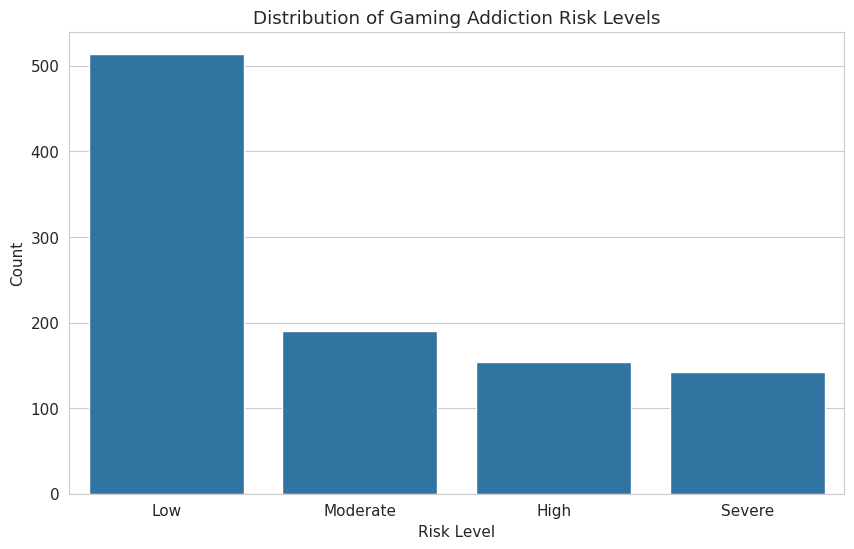

In [10]:
sns.countplot(data=df, x="gaming_addiction_risk_level", order=df["gaming_addiction_risk_level"].value_counts().index)
plt.title("Distribution of Gaming Addiction Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

### 🔍 Insight
The dataset is clearly imbalanced, with the **Low risk level dominating the distribution**, while Moderate, High, and especially Severe appear less frequently.

### 🧠 Interpretation
This class imbalance can negatively impact model performance, as the model may become biased toward predicting the majority class (Low) and fail to correctly identify minority classes such as Severe.

Therefore, handling imbalance using techniques like **class weighting, SMOTE, or resampling** is essential to improve model generalization and ensure fair performance across all classes.

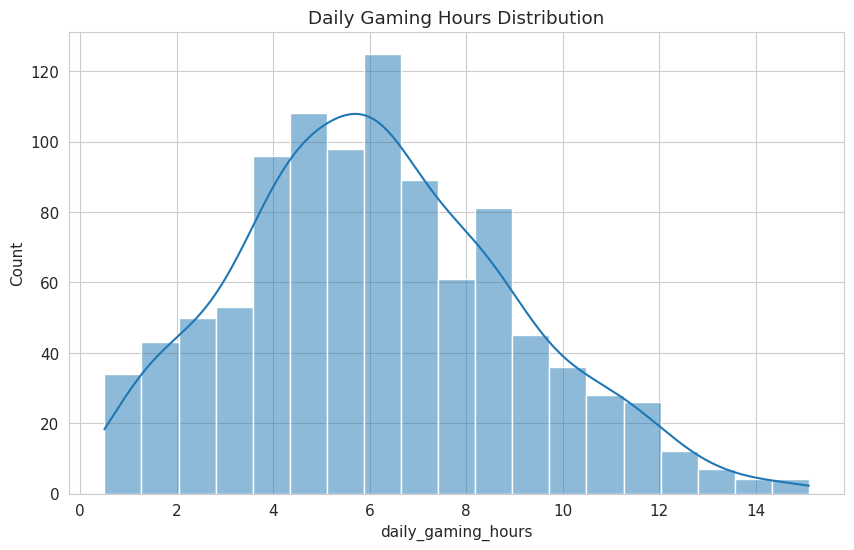

In [11]:
sns.histplot(df["daily_gaming_hours"], kde=True)
plt.title("Daily Gaming Hours Distribution")
plt.show()

### 🔍 Insight
The distribution of daily gaming hours is slightly right-skewed, with most users spending between **4 to 8 hours per day**, and a peak around **5–6 hours**.

### 🧠 Interpretation
The right-skewness indicates that while the majority of users engage in moderate gaming durations, there is a smaller group of users who spend significantly higher hours (10+), representing potential high-risk behavior.

This suggests that extreme gaming patterns exist but are less frequent, and these cases may play a critical role in predicting gaming addiction risk levels.

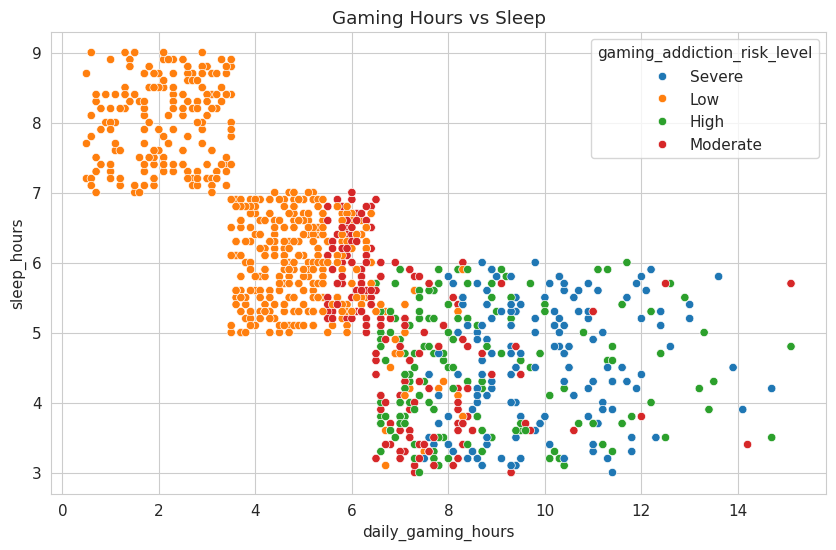

In [12]:
sns.scatterplot(
    data=df,
    x="daily_gaming_hours",
    y="sleep_hours",
    hue="gaming_addiction_risk_level"
)
plt.title("Gaming Hours vs Sleep")
plt.show()

### 🔍 Insight
There is a negative relationship between gaming hours and sleep hours; as gaming increases, sleep decreases.

### 🧠 Interpretation
This suggests that higher gaming hours are associated with higher addiction risk, making these features important for prediction.

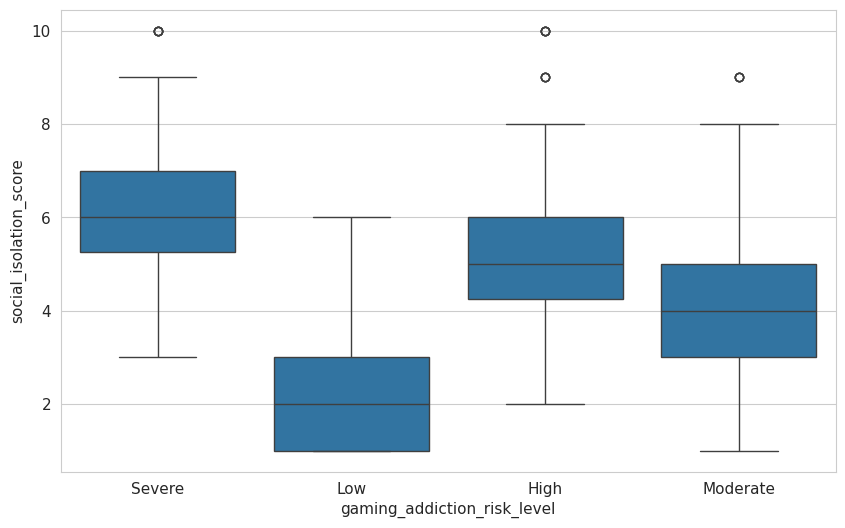

In [13]:
sns.boxplot(data=df, x="gaming_addiction_risk_level", y="social_isolation_score")
plt.show()

### 🔍 Insight
Social isolation scores increase as addiction risk level increases, with Severe having the highest values and Low the lowest.

### 🧠 Interpretation
This suggests a strong relationship between social isolation and gaming addiction, making it an important feature for predicting risk levels.

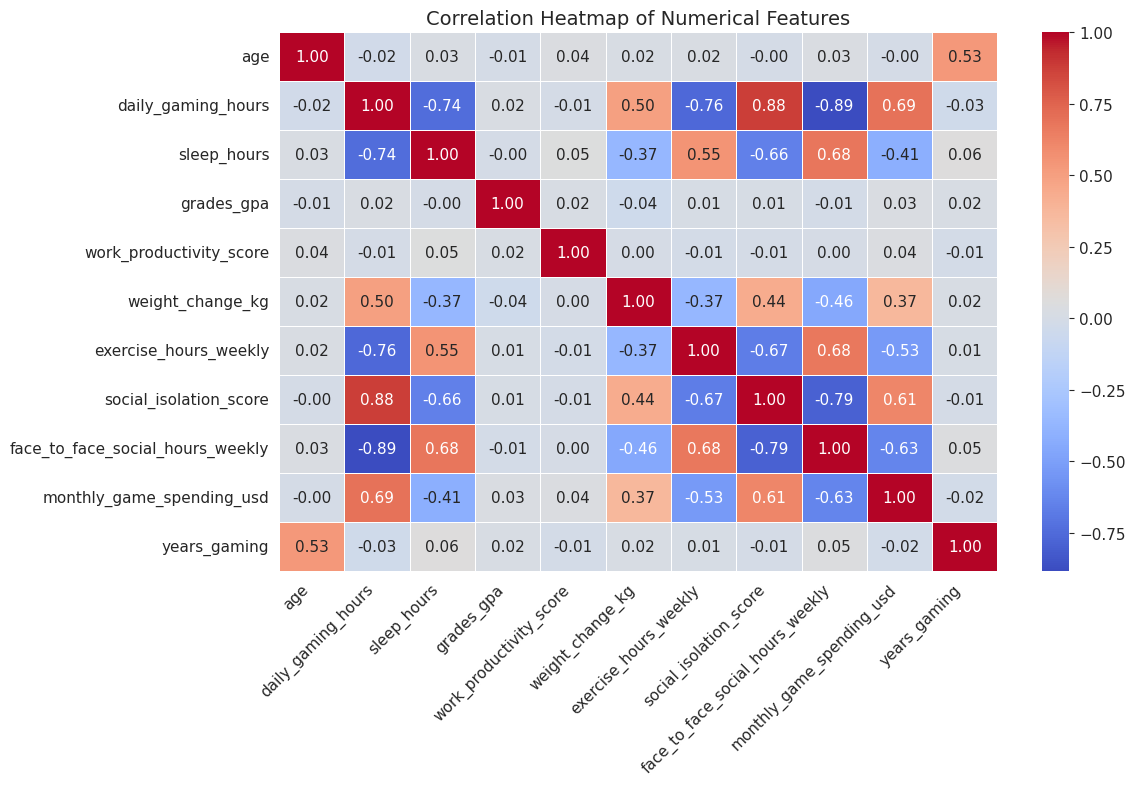

In [14]:
plt.figure(figsize=(12, 8))

corr_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 🔍 Insight
The heatmap shows strong relationships between several behavioral features, especially daily gaming hours, sleep hours, social isolation, and face-to-face social hours.

### 🧠 Interpretation
These correlations suggest that gaming addiction is linked not to a single factor, but to a combination of connected behaviors. Features with stronger positive or negative correlations may provide valuable predictive power for the model.

## ✂️ Defining Features and Target

We separate:
- **X** = input features
- **y** = target variable

The target is then encoded into numeric class labels for model training.

In [15]:
X = df.drop("gaming_addiction_risk_level", axis=1)
y = df["gaming_addiction_risk_level"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Encoded classes:
0 -> High
1 -> Low
2 -> Moderate
3 -> Severe


## ⚙️ Data Splitting and Preprocessing

The dataset is split into:
- 80% training data
- 20% testing data

### Preprocessing Strategy

A single preprocessing pipeline is used for all models to ensure consistency and fairness.

#### Numerical features:
- missing values are filled using the median

#### Categorical features:
- missing values are filled using the most frequent value
- One-Hot Encoding is applied

Using one preprocessing pipeline for all models ensures that any performance differences are due to the models themselves, not differences in data preparation.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [17]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

## 🤖 Baseline Model Training

We first train two baseline models:

1. **Gradient Boosting**
2. **XGBoost**

These baseline models allow us to compare performance under the same preprocessing setup before applying any advanced optimization.

In [18]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    random_state=42
)

gb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", gb)
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'daily_gaming_hours',
                                                   'sleep_hours', 'grades_gpa',
                                                   'work_productivity_score',
                                                   'weight_change_kg',
                                                   'exercise_hours_weekly',
                                                   'social_isolation_score',
                                                   'face_to_face_social_hours_weekly',
                                                   'monthly_game_spending_usd',
                                                   'years_gamin...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['record_id', 'gender',
                                                   'game_genre', 'primary_game',
                                                   'gaming_platform',
                                                   'sleep_quality',
                                                   'sleep_disruption_frequency',
                                                   'academic_work_performance',
                                                   'mood_state',
                                                   'mood_swing_frequency'])])),
                ('model',
                 GradientBoostingClassifier(n_estimators=150,
                                            random_state=42))])

In [19]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'daily_gaming_hours',
                                                   'sleep_hours', 'grades_gpa',
                                                   'work_productivity_score',
                                                   'weight_change_kg',
                                                   'exercise_hours_weekly',
                                                   'social_isolation_score',
                                                   'face_to_face_social_hours_weekly',
                                                   'monthly_game_spending_usd',
                                                   'years_gamin...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 📊 Baseline Model Evaluation

We evaluate both baseline models using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

This provides a fair and comprehensive comparison.

In [20]:
y_pred_gb = gb_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)

In [21]:
print("🔹 Gradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb, target_names=label_encoder.classes_))

🔹 Gradient Boosting Classification Report:

              precision    recall  f1-score   support

        High       0.35      0.19      0.25        31
         Low       0.94      0.84      0.89       103
    Moderate       0.43      0.66      0.52        38
      Severe       0.62      0.71      0.67        28

    accuracy                           0.69       200
   macro avg       0.59      0.60      0.58       200
weighted avg       0.71      0.69      0.69       200



In [22]:
print("🔹 XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

🔹 XGBoost Classification Report:

              precision    recall  f1-score   support

        High       0.32      0.23      0.26        31
         Low       0.89      0.87      0.88       103
    Moderate       0.38      0.47      0.42        38
      Severe       0.67      0.71      0.69        28

    accuracy                           0.68       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.67      0.68      0.67       200



## 🔍 Confusion Matrix

The confusion matrix shows how well the model predicts each class.

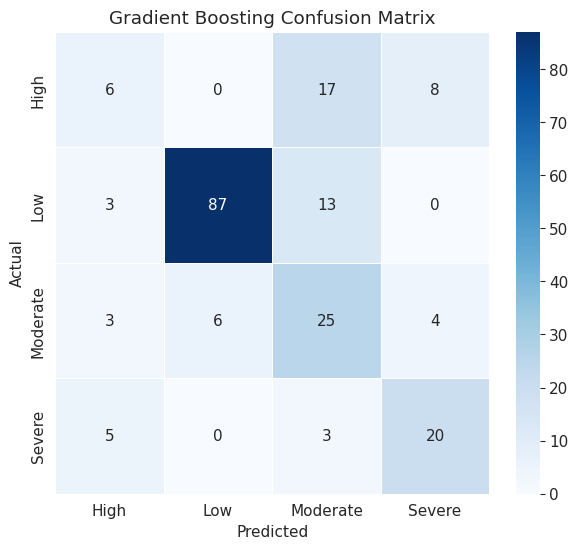

In [23]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_gb),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

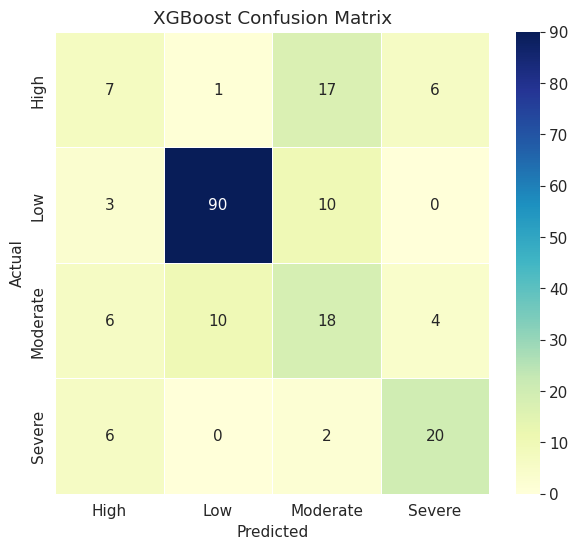

In [24]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
    linecolor="white"
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 📈 Baseline Comparison Between Models

To compare the two baseline models fairly, we calculate:
- Accuracy
- Precision
- Recall
- F1 Score

In [25]:
gb_acc = accuracy_score(y_test, y_pred_gb)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

gb_precision = precision_score(y_test, y_pred_gb, average="weighted")
xgb_precision = precision_score(y_test, y_pred_xgb, average="weighted")

gb_recall = recall_score(y_test, y_pred_gb, average="weighted")
xgb_recall = recall_score(y_test, y_pred_xgb, average="weighted")

gb_f1 = f1_score(y_test, y_pred_gb, average="weighted")
xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

baseline_comparison = pd.DataFrame({
    "Model": ["Gradient Boosting", "XGBoost"],
    "Accuracy": [gb_acc, xgb_acc],
    "Precision": [gb_precision, xgb_precision],
    "Recall": [gb_recall, xgb_recall],
    "F1 Score": [gb_f1, xgb_f1]
})

baseline_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.690,0.705877,0.690,0.688236
1,XGBoost,0.675,0.674328,0.675,0.672377


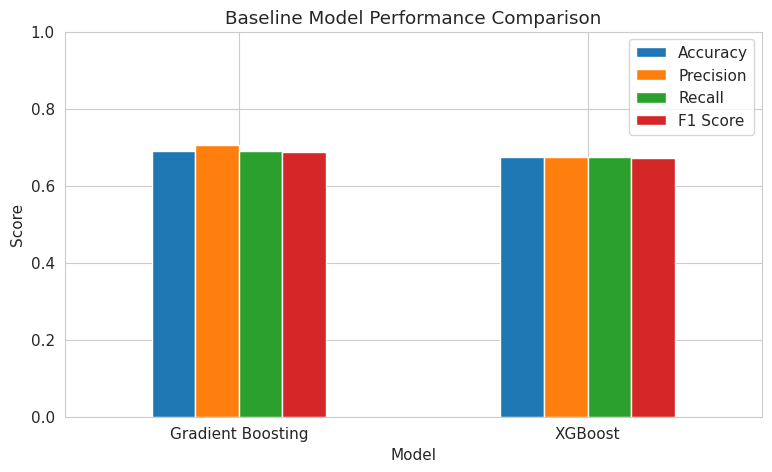

In [26]:
baseline_comparison.set_index("Model").plot(kind="bar", figsize=(9, 5))
plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## 🚀 Improving XGBoost

After comparing the baseline models, XGBoost was selected for further improvement because it achieved better initial performance.

### Improvement Strategy
To make the model stronger and more reliable, we apply:

- class balancing using sample weights
- stratified cross-validation
- hyperparameter tuning using RandomizedSearchCV

This helps improve generalization and reduces bias toward the majority class.

In [27]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [28]:
xgb_tuned = XGBClassifier(
    objective="multi:softprob",
    random_state=42,
    eval_metric="mlogloss"
)

xgb_tuned_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_tuned)
])

In [29]:
param_dist = {
    "model__n_estimators": [150, 200, 250, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_weighted",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train, model__sample_weight=sample_weights)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['age',
                                                                                'daily_gaming_hours',
                                                                                'sleep_hours',
                                                                                'grades_gpa',
                                                                                'work_productivity_score',
                                                                                'weight_change_kg',
                                                                                'exercise_hours_weekly',
                                                                                'social_iso...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=1,
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.08, 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [150, 200, 250,
                                                                300],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [32]:
best_xgb = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Score (Weighted F1):")
print(random_search.best_score_)

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 250, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}

Best Cross-Validation Score (Weighted F1):
0.7181681391762851


## ✅ Evaluation of Tuned XGBoost

Now we evaluate the optimized XGBoost model on the test set using the same metrics as before.

In [33]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

In [34]:
xgb_tuned_acc = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision = precision_score(y_test, y_pred_xgb_tuned, average="weighted")
xgb_tuned_recall = recall_score(y_test, y_pred_xgb_tuned, average="weighted")
xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned, average="weighted")

print("🔹 Tuned XGBoost Results\n")
print("Accuracy :", xgb_tuned_acc)
print("Precision:", xgb_tuned_precision)
print("Recall   :", xgb_tuned_recall)
print("F1 Score :", xgb_tuned_f1)

🔹 Tuned XGBoost Results

Accuracy : 0.725
Precision: 0.7370684063098922
Recall   : 0.725
F1 Score : 0.7252911810054009


In [35]:
print("🔹 Tuned XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=label_encoder.classes_))

🔹 Tuned XGBoost Classification Report:

              precision    recall  f1-score   support

        High       0.43      0.29      0.35        31
         Low       0.95      0.87      0.91       103
    Moderate       0.47      0.63      0.54        38
      Severe       0.67      0.79      0.72        28

    accuracy                           0.72       200
   macro avg       0.63      0.65      0.63       200
weighted avg       0.74      0.72      0.73       200



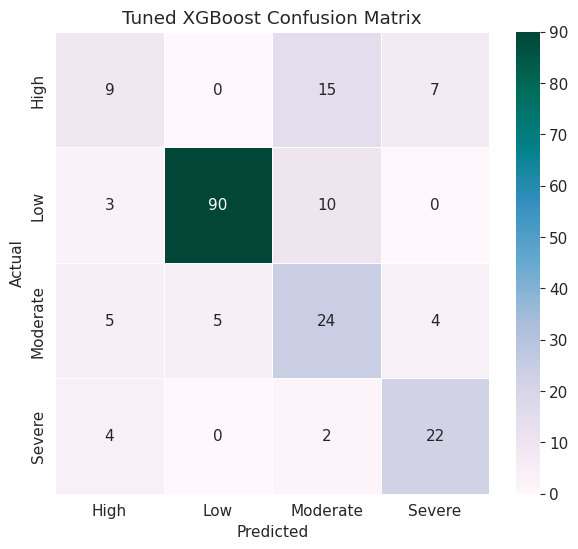

In [36]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb_tuned),
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🏁 Final Comparison

Finally, we compare:
1. Gradient Boosting (baseline)
2. XGBoost (baseline)
3. XGBoost (tuned)

This shows whether tuning and cross-validation actually improved performance.

In [37]:
final_comparison = pd.DataFrame({
    "Model": ["Gradient Boosting", "XGBoost", "Tuned XGBoost"],
    "Accuracy": [gb_acc, xgb_acc, xgb_tuned_acc],
    "Precision": [gb_precision, xgb_precision, xgb_tuned_precision],
    "Recall": [gb_recall, xgb_recall, xgb_tuned_recall],
    "F1 Score": [gb_f1, xgb_f1, xgb_tuned_f1]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.690,0.705877,0.690,0.688236
1,XGBoost,0.675,0.674328,0.675,0.672377
2,Tuned XGBoost,0.725,0.737068,0.725,0.725291


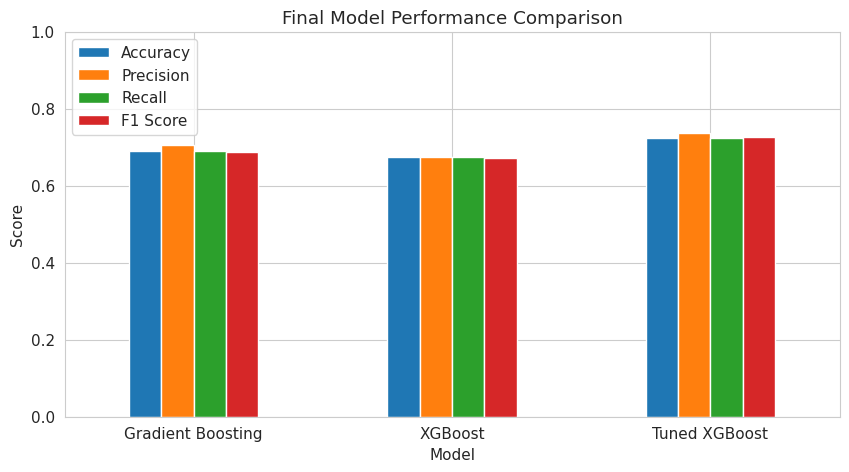

In [38]:
final_comparison.set_index("Model").plot(kind="bar", figsize=(10, 5))
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

### 🔍 Insight
Tuned XGBoost achieved the highest performance across all evaluation metrics compared to the other models.

### 🧠 Interpretation
This indicates that hyperparameter tuning significantly improved model performance, making Tuned XGBoost the best choice for this classification task.

## 🌟 Feature Importance

Feature importance helps identify which variables contribute most to predicting gaming addiction risk.

In [39]:
prep_fitted = preprocessor.fit(X_train)

encoded_cat_names = prep_fitted.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

X_train_transformed = prep_fitted.transform(X_train)

xgb_feature_model = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric="mlogloss"
)

# Remove pipeline prefixes from parameter names
clean_params = {}
for k, v in random_search.best_params_.items():
    clean_params[k.replace("model__", "")] = v

xgb_feature_model = XGBClassifier(
    **clean_params,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_feature_model.fit(X_train_transformed, y_train, sample_weight=sample_weights)

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": xgb_feature_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,daily_gaming_hours,0.099239
7,social_isolation_score,0.031566
824,primary_game_Call of Duty,0.023297
828,primary_game_Cyberpunk 2077,0.022890
870,mood_state_Irritable,0.021599
831,primary_game_Elder Scrolls Online,0.020314
822,primary_game_Apex Legends,0.019998
838,primary_game_PUBG,0.018442
846,gaming_platform_Mobile,0.018057
830,primary_game_Elden Ring,0.017198


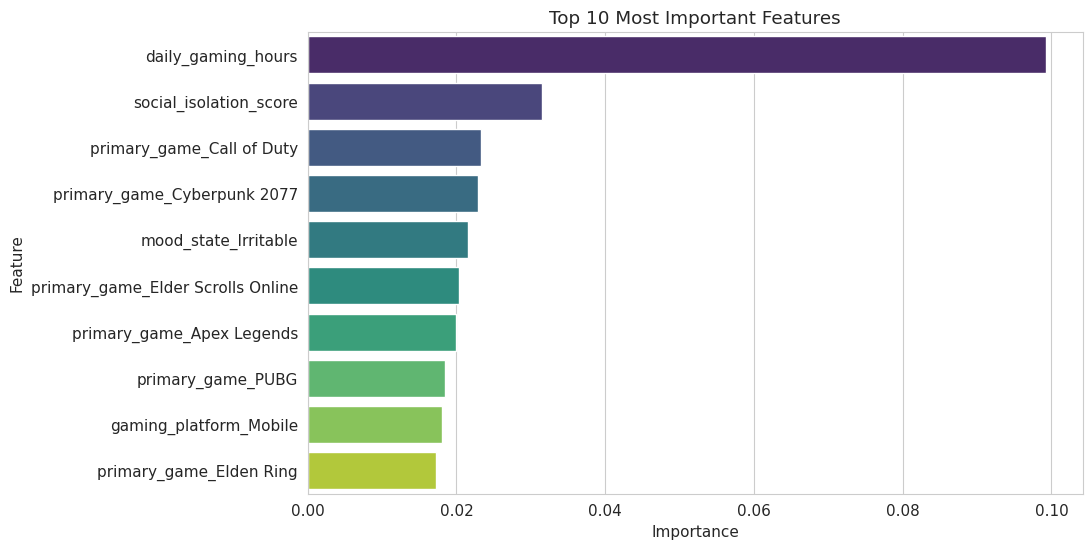

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### 🔍 Insight
Daily gaming hours is the most important feature, followed by social isolation score, while other features contribute less.

### 🧠 Interpretation
This shows that gaming behavior is the main driver of addiction risk, with social and psychological factors also playing a supporting role in prediction.

We also compare with Another Classification model ( KNN model ):

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [42]:
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_knn = ColumnTransformer([
    ("num", num_pipeline_scaled, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

In [43]:
knn = KNeighborsClassifier(n_neighbors=5)
knn_pipeline = Pipeline([
    ("prep", preprocessor_knn),
    ("model", knn)
])

In [44]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'daily_gaming_hours',
                                                   'sleep_hours', 'grades_gpa',
                                                   'work_productivity_score',
                                                   'weight_change_kg',
                                                   'exercise_hours_weekly',
                                                   'social_isolation_score',
                                                   'face_to_face_social_hours_weekly',
                                                   'monthly_gam...
                                                   'years_gaming']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['record_id', 'gender',
                                                   'game_genre', 'primary_game',
                                                   'gaming_platform',
                                                   'sleep_quality',
                                                   'sleep_disruption_frequency',
                                                   'academic_work_performance',
                                                   'mood_state',
                                                   'mood_swing_frequency'])])),
                ('model', KNeighborsClassifier())])

In [45]:
y_pred_knn = knn_pipeline.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="weighted")
knn_recall = recall_score(y_test, y_pred_knn, average="weighted")
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

In [46]:
final_comparison = pd.concat([
    final_comparison,
    pd.DataFrame({
        "Model": ["KNN (k=5)"],
        "Accuracy": [knn_acc],
        "Precision": [knn_precision],
        "Recall": [knn_recall],
        "F1 Score": [knn_f1]
    })
], ignore_index=True)

In [47]:
print(final_comparison)

               Model  Accuracy  Precision  Recall  F1 Score
0  Gradient Boosting     0.690   0.705877   0.690  0.688236
1            XGBoost     0.675   0.674328   0.675  0.672377
2      Tuned XGBoost     0.725   0.737068   0.725  0.725291
3          KNN (k=5)     0.660   0.627889   0.660  0.638018


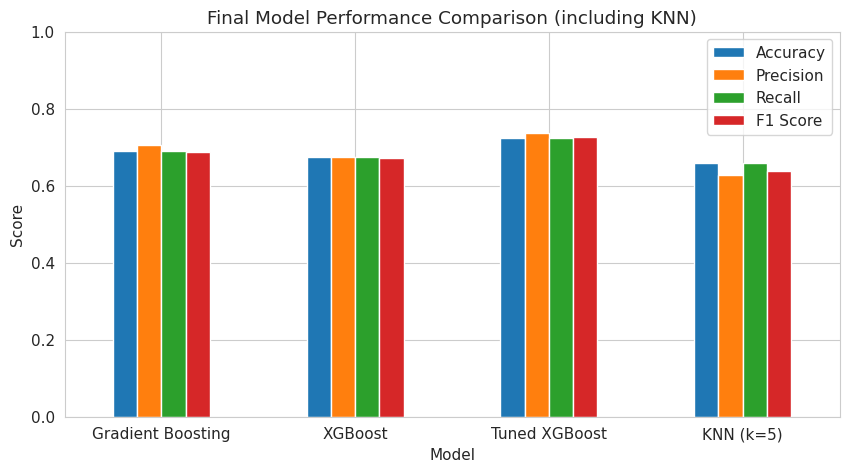

In [48]:
final_comparison.set_index("Model").plot(kind="bar", figsize=(10, 5))
plt.title("Final Model Performance Comparison (including KNN)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

### 🔍 Insight
Tuned XGBoost is the best-performing model, KNN (k=5) is the weakest model

### 🧠 Interpretation
This shows that Tuned XGBoost is the most effective model for this dataset, as optimizing its parameters leads to the highest overall predictive performance. Tree-based models (Gradient Boosting and XGBoost) capture the data patterns better, while KNN performs weaker, indicating that distance-based methods are less suitable for this type of structured data.

## 🧠 Key Insights from the Project
- Daily gaming hours is the most influential factor in predicting gaming addiction risk.
- Social isolation and reduced face-to-face interaction are strongly associated with higher risk levels.
- There is a clear negative relationship between gaming hours and sleep duration.
- Behavioral features are more impactful than demographic features like age.
- The dataset is imbalanced, which may affect performance on minority classes.

## 🧾 Conclusion
This project demonstrates that gaming addiction risk can be effectively predicted using machine learning techniques, particularly tree-based models such as Gradient Boosting and XGBoost. Among all models, the Tuned XGBoost achieved the highest performance across all evaluation metrics, confirming the importance of hyperparameter tuning in improving model effectiveness.

The analysis revealed that addiction risk is primarily driven by behavioral factors, especially daily gaming hours, followed by social isolation and reduced social interaction. These findings are supported by both the feature importance results and the correlation analysis, which showed strong relationships between gaming habits, sleep patterns, and social behavior.

Additionally, the dataset showed a noticeable class imbalance, which can impact model performance, especially for minority classes. Addressing this issue is essential to ensure fair and reliable predictions across all risk levels.

Overall, the project highlights how combining data preprocessing, feature analysis, and model optimization leads to more accurate and interpretable results, making the model suitable for real-world applications in identifying and managing gaming addiction risk.

## ✍️ Reflection
This project emphasized the importance of data preprocessing, handling missing values, and addressing class imbalance.

It also showed how model tuning and data visualization improve both performance and understanding of the problem.